## Season_Performance_Dashboard_LaLiga_2015_16

In [3]:
!pip install mplsoccer statsbombpy -q

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mplsoccer import Pitch
from statsbombpy import sb

# Load La Liga 2015/2016
matches = sb.matches(competition_id=11, season_id=26)

# Load all events
all_events = []
for match_id in matches['match_id']:
    try:
        events = sb.events(match_id=match_id)
        all_events.append(events)
    except:
        pass

all_events = pd.concat(all_events, ignore_index=True)
print(f"Total events loaded: {len(all_events)}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.5 MB/s eta 0:00:00
Total events loaded: 142957


In [4]:
# ── Build season stats for Barcelona and opponents ────────────────────────

shots = all_events[all_events['type'] == 'Shot'].copy()
passes = all_events[all_events['type'] == 'Pass'].copy()
pressure = all_events[all_events['type'] == 'Pressure'].copy()

shots['x'] = shots['location'].apply(lambda loc: loc[0])
passes['x'] = passes['location'].apply(lambda loc: loc[0])

# Goals
barca_goals = len(shots[
    (shots['team'] == 'Barcelona') &
    (shots['shot_outcome'] == 'Goal')
])
opponent_goals = len(shots[
    (shots['team'] != 'Barcelona') &
    (shots['shot_outcome'] == 'Goal')
])

# xG
barca_xg = shots[shots['team'] == 'Barcelona']['shot_statsbomb_xg'].sum()
opponent_xg = shots[shots['team'] != 'Barcelona']['shot_statsbomb_xg'].sum()

# Passes
barca_passes = len(passes[passes['team'] == 'Barcelona'])
opponent_passes = len(passes[passes['team'] != 'Barcelona'])

# Pressures
barca_press = len(pressure[pressure['team'] == 'Barcelona'])
opponent_press = len(pressure[pressure['team'] != 'Barcelona'])

print(f"Barcelona goals: {barca_goals} | Opponents goals: {opponent_goals}")
print(f"Barcelona xG: {barca_xg:.2f} | Opponents xG: {opponent_xg:.2f}")
print(f"Barcelona passes: {barca_passes} | Opponents passes: {opponent_passes}")
print(f"Barcelona pressures: {barca_press} | Opponents pressures: {opponent_press}")

Barcelona goals: 108 | Opponents goals: 19
Barcelona xG: 84.08 | Opponents xG: 26.69
Barcelona passes: 27470 | Opponents passes: 12307
Barcelona pressures: 4592 | Opponents pressures: 7637


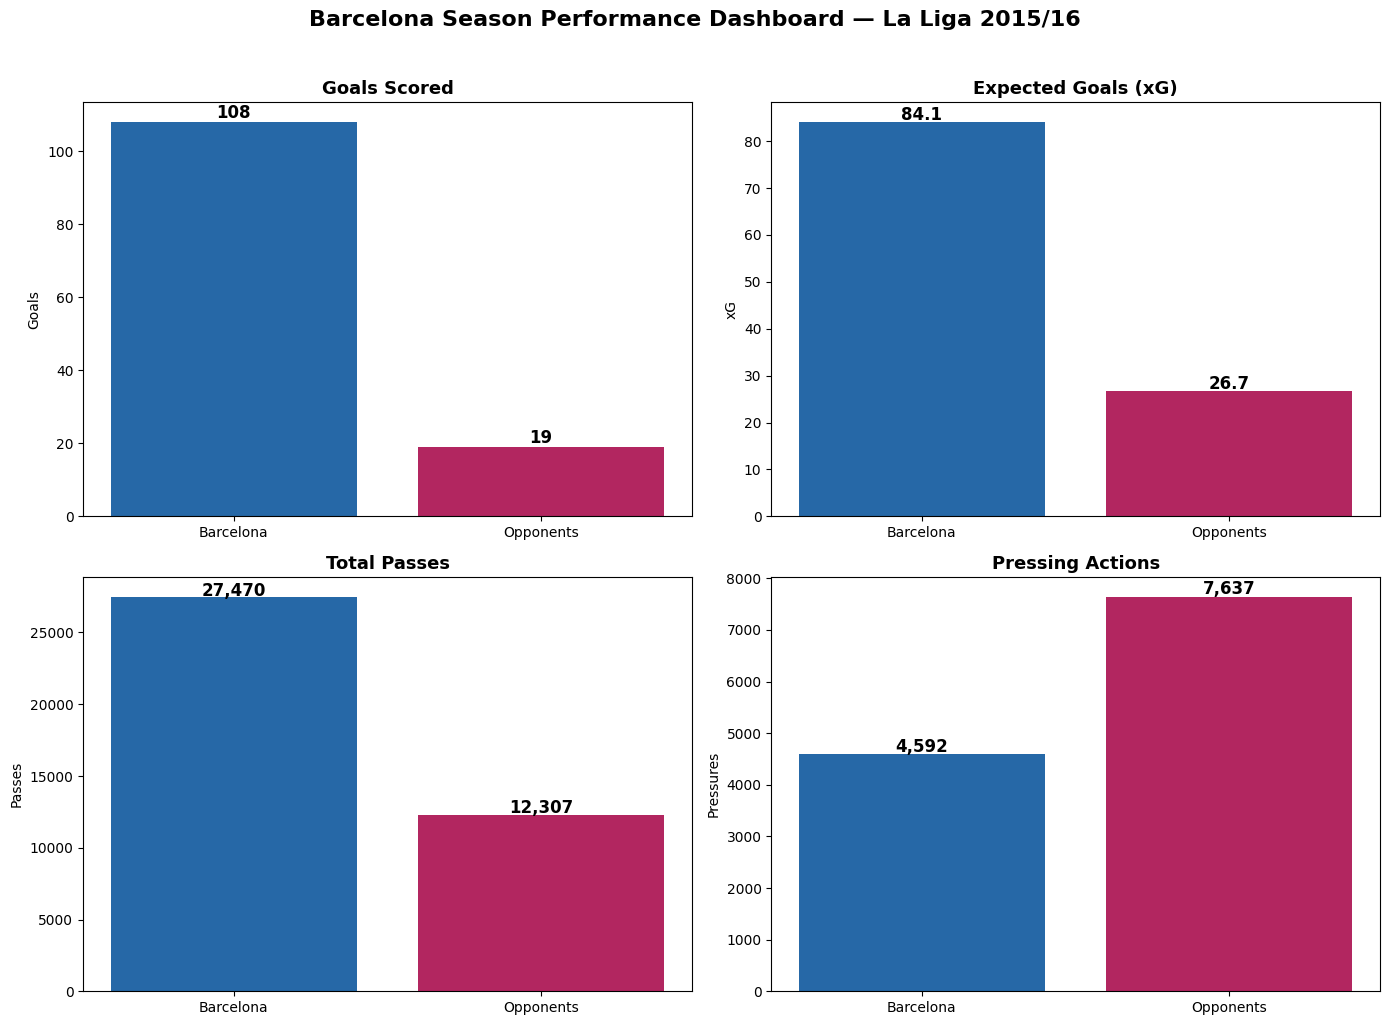

Dashboard saved


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Barcelona Season Performance Dashboard — La Liga 2015/16',
             fontsize=16, fontweight='bold', y=1.02)

categories = ['Barcelona', 'Opponents']
colors = ['#004D98', '#A50044']

# ── Goals ────────────────────────────────────────────────────────────────
axes[0,0].bar(categories, [barca_goals, opponent_goals], color=colors, alpha=0.85)
axes[0,0].set_title('Goals Scored', fontsize=13, fontweight='bold')
axes[0,0].set_ylabel('Goals')
for i, v in enumerate([barca_goals, opponent_goals]):
    axes[0,0].text(i, v + 1, str(v), ha='center', fontweight='bold', fontsize=12)

# ── xG ───────────────────────────────────────────────────────────────────
axes[0,1].bar(categories, [barca_xg, opponent_xg], color=colors, alpha=0.85)
axes[0,1].set_title('Expected Goals (xG)', fontsize=13, fontweight='bold')
axes[0,1].set_ylabel('xG')
for i, v in enumerate([barca_xg, opponent_xg]):
    axes[0,1].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold', fontsize=12)

# ── Passes ────────────────────────────────────────────────────────────────
axes[1,0].bar(categories, [barca_passes, opponent_passes], color=colors, alpha=0.85)
axes[1,0].set_title('Total Passes', fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('Passes')
for i, v in enumerate([barca_passes, opponent_passes]):
    axes[1,0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold', fontsize=12)

# ── Pressures ────────────────────────────────────────────────────────────
axes[1,1].bar(categories, [barca_press, opponent_press], color=colors, alpha=0.85)
axes[1,1].set_title('Pressing Actions', fontsize=13, fontweight='bold')
axes[1,1].set_ylabel('Pressures')
for i, v in enumerate([barca_press, opponent_press]):
    axes[1,1].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('season_dashboard.png', dpi=200, bbox_inches='tight')
plt.show()
print("Dashboard saved")

Barcelona's season performance dashboard tells the story of the most dominant possession team in modern football. With 27,470 passes compared to their opponents' 12,307, Barcelona had the ball for the majority of every match across the season. This possession dominance directly translated into attacking superiority — 108 goals scored against only 19 conceded, with an xG of 84.1 compared to opponents' 26.7, showing they not only scored more but created significantly higher quality chances. The pressing chart completes the picture — Barcelona made only 4,592 pressing actions compared to opponents' 7,637, confirming that they did not need to press because they rarely gave the ball away. This is the data fingerprint of Pep Guardiola's possession philosophy — control the ball, control the game, control the result.

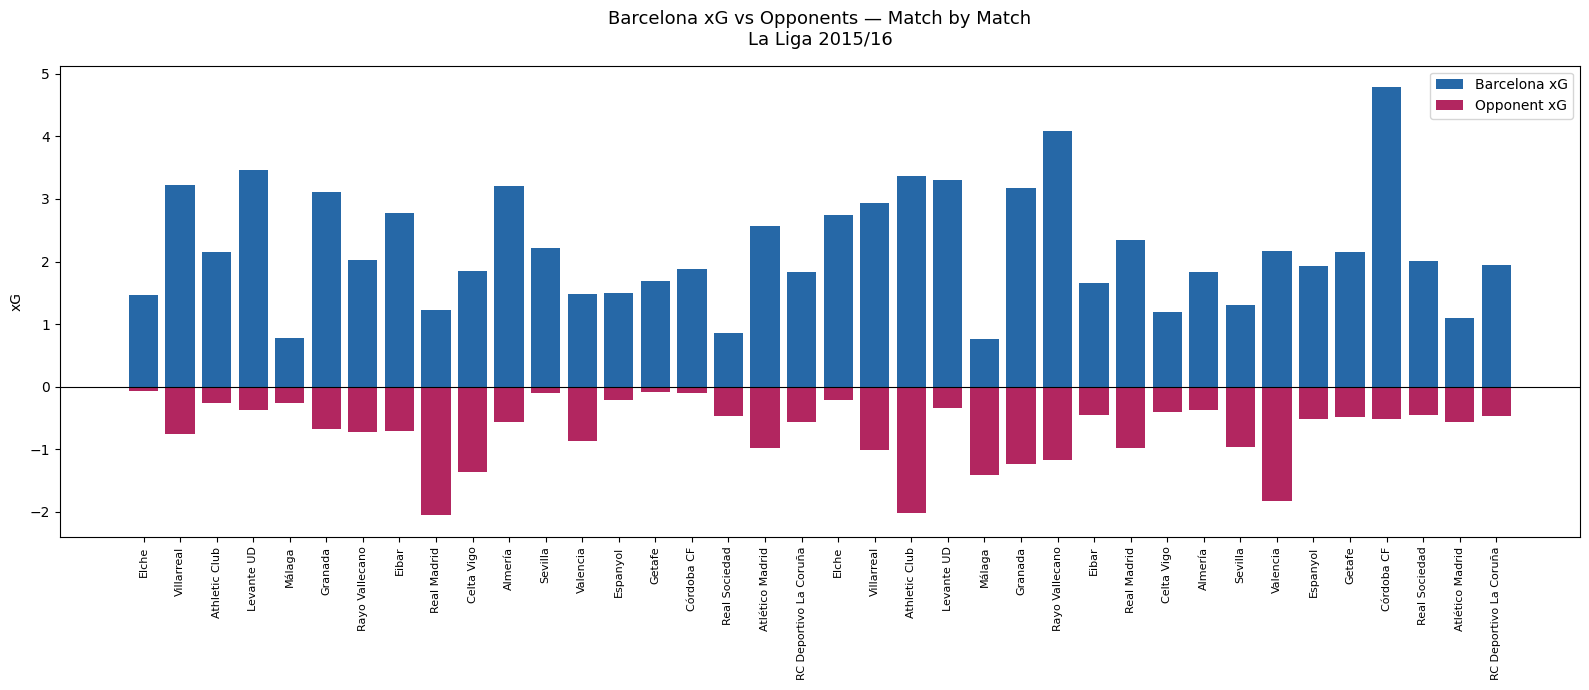

In [6]:
# xG per match
match_xg = []

for _, match in matches.iterrows():
    match_events = all_events[all_events['match_id'] == match['match_id']]
    match_shots = match_events[match_events['type'] == 'Shot']

    barca_xg_match = match_shots[
        match_shots['team'] == 'Barcelona'
    ]['shot_statsbomb_xg'].sum()

    opponent_xg_match = match_shots[
        match_shots['team'] != 'Barcelona'
    ]['shot_statsbomb_xg'].sum()

    opponent = match['away_team'] if match['home_team'] == 'Barcelona' else match['home_team']

    match_xg.append({
        'opponent': opponent,
        'barca_xg': round(barca_xg_match, 2),
        'opponent_xg': round(opponent_xg_match, 2),
        'match_date': match['match_date']
    })

match_xg_df = pd.DataFrame(match_xg).sort_values('match_date')

fig, ax = plt.subplots(figsize=(16, 7))

x = range(len(match_xg_df))
ax.bar(x, match_xg_df['barca_xg'], color='#004D98', alpha=0.85, label='Barcelona xG')
ax.bar(x, [-v for v in match_xg_df['opponent_xg']], color='#A50044',
       alpha=0.85, label='Opponent xG')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(match_xg_df['opponent'], rotation=90, fontsize=8)
ax.set_ylabel('xG')
ax.set_title('Barcelona xG vs Opponents — Match by Match\nLa Liga 2015/16',
             fontsize=13, pad=15)
ax.legend()
plt.tight_layout()
plt.savefig('match_xg.png', dpi=200, bbox_inches='tight')
plt.show()

The match by match xG chart shows that Barcelona dominated chance creation in over 90% of their matches across the season, consistently generating higher xG than their opponents. Their highest xG came against Córdoba CF, one of the weakest teams in the league that season, where Barcelona created chances at will against a defense that was eventually relegated. Their biggest struggle came against Real Madrid — the only team in La Liga with the tactical quality and defensive discipline to genuinely limit Barcelona's chance creation. That single data point tells you more about El Clásico than any highlight reel.